# 📱 PhonePe Digital Payments — Case Study
**Analyzing Transaction and Demographic Data across India**

This notebook explores PhonePe transaction data spanning multiple years and quarters across Indian states and districts. The goal is to identify transaction trends, device preferences, demographic correlations, and derive actionable insights from the data.

### ⚙️ Setup — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

print("✅ Libraries loaded successfully.")

Setup complete.


---
## 🧭 Task 1 — Data Loading and Understanding

### 1.1 Load each dataset

In [2]:
FILE = "phonepe-pulse_raw-data.xlsx"

state_txn    = pd.read_excel(FILE, sheet_name="State_Txn and Users")
state_split  = pd.read_excel(FILE, sheet_name="State_TxnSplit")
state_device = pd.read_excel(FILE, sheet_name="State_DeviceData")
dist_txn     = pd.read_excel(FILE, sheet_name="District_Txn and Users")
dist_demo    = pd.read_excel(FILE, sheet_name="District Demographics")

datasets = [
    (state_txn,    "State_Txn and Users"),
    (state_split,  "State_TxnSplit"),
    (state_device, "State_DeviceData"),
    (dist_txn,     "District_Txn and Users"),
    (dist_demo,    "District Demographics"),
]

print("Datasets loaded:\n")
for df, name in datasets:
    print(f"  {name}: {df.shape[0]:,} rows x {df.shape[1]} columns")

Datasets loaded:

  State_Txn and Users: 504 rows x 8 columns
  State_TxnSplit: 2,514 rows x 7 columns
  State_DeviceData: 5,544 rows x 6 columns
  District_Txn and Users: 10,248 rows x 10 columns
  District Demographics: 742 rows x 8 columns


In [3]:
# State_Txn and Users — first 5 rows
print("State_Txn and Users — first 5 rows")
state_txn.head()

State_Txn and Users — first 5 rows


,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,"14,631,761.22","2,197.62",6740,0
1,Andaman & Nicobar Islands,2018,2,11340,"28,338,535.51","2,498.99",9405,0
2,Andaman & Nicobar Islands,2018,3,16265,"55,557,471.13","3,415.77",12149,0
3,Andaman & Nicobar Islands,2018,4,23758,"90,548,336.07","3,811.28",15222,0
4,Andaman & Nicobar Islands,2019,1,30486,"102,299,740.67","3,355.63",18596,0


In [4]:
# State_TxnSplit — last 10 rows
print("State_TxnSplit — last 10 rows")
state_split.tail(10)

State_TxnSplit — last 10 rows


,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,"202,240,249,482.85","3,754.29"
2505,West Bengal,2021,1,Merchant payments,37143701,"28,918,343,691.02",778.55
2506,West Bengal,2021,1,Recharge & bill payments,26673733,"11,339,665,944.69",425.12
2507,West Bengal,2021,1,Financial Services,166727,"175,445,811.88","1,052.29"
2508,West Bengal,2021,1,Others,400816,"263,502,545.07",657.42
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,"230,812,278,789.30","3,569.57"
2510,West Bengal,2021,2,Merchant payments,41696787,"34,787,867,208.32",834.31
2511,West Bengal,2021,2,Recharge & bill payments,34799709,"13,331,453,857.61",383.09
2512,West Bengal,2021,2,Financial Services,190537,"186,466,487.63",978.64
2513,West Bengal,2021,2,Others,549353,"316,744,715.70",576.58


In [5]:
# State_DeviceData — 10 rows from the middle
mid = len(state_device) // 2
print(f"State_DeviceData — rows {mid} to {mid+9}")
state_device.iloc[mid : mid + 10]

State_DeviceData — rows 2772 to 2781


,State,Year,Quarter,Brand,Registered Users,Percentage
2772,Lakshadweep,2018,1,Samsung,102,0.20
2773,Lakshadweep,2018,1,Xiaomi,100,0.20
2774,Lakshadweep,2018,1,Vivo,67,0.13
2775,Lakshadweep,2018,1,Oppo,56,0.11
2776,Lakshadweep,2018,1,Huawei,25,0.05
2777,Lakshadweep,2018,1,OnePlus,22,0.04
2778,Lakshadweep,2018,1,Apple,20,0.04
2779,Lakshadweep,2018,1,Realme,20,0.04
2780,Lakshadweep,2018,1,Gionee,12,0.02
2781,Lakshadweep,2018,1,COOLPAD,10,0.02


In [6]:
# District_Txn and Users — first 10 and last 10
print("District_Txn and Users — first 10")
display(dist_txn.head(10))

print("District_Txn and Users — last 10")
dist_txn.tail(10)

District_Txn and Users — first 10


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,"1,139,848.80","2,158.80",262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,"931,663.08","2,107.84",632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,"12,560,249.34","2,208.20",5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,"3,072,436.91","2,743.25",351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,"1,317,863.08","1,597.41",911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,"23,948,235.52","2,549.04",8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,"6,387,829.15","4,342.51",467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,"4,901,529.52","3,820.37",1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,"44,268,112.46","3,276.45",10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,"7,180,859.35","4,835.60",536,0


District_Txn and Users — last 10


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,"19,996,935,608.24","2,324.62",1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,"11,227,582,723.38","2,032.45",955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,"30,414,821,772.93","1,762.33",2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,"8,731,262,893.73","1,784.16",789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,"10,303,513,378.80","2,039.56",856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,"7,572,502,416.24","1,931.40",787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,"15,155,067,721.27","2,361.15",946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,"2,790,996,372.04","1,472.06",435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,"13,398,529,483.67","2,011.24",1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,"5,564,220,751.05","2,469.27",392388,8184990


In [7]:
# District Demographics — every 10th row
print("District Demographics — every 10th row")
dist_demo.iloc[::10]

District Demographics — every 10th row


,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,"19,130.00",213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,"11,161.00",384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.00,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,"2,919.00",11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,"3,245.00",520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.00,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,"3,097.00",596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.00,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.00,14557,DL04,North


### 1.2 Summary statistics and data types

In [8]:
for df, name in datasets:
    print(f"\n{'─'*55}")
    print(f"  {name}  |  {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(f"{'─'*55}")
    display(df.describe())
    display(df.dtypes.rename("dtype").to_frame())


───────────────────────────────────────────────────────
  State_Txn and Users  |  504 rows x 8 cols
───────────────────────────────────────────────────────


,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.00,504.00,504.00,503.00,504.00,504.00,504.00
mean,"2,019.29",2.36,"40,740,000.58","70,833,320,601.59","1,993.47","4,777,500.89","97,744,705.23"
std,1.03,1.11,"82,287,143.49","144,090,233,156.01",607.46,"6,644,495.72","204,237,579.80"
min,"2,018.00",1.00,778.00,"1,928,611.18",0.00,501.00,0.00
25%,"2,018.00",1.00,"592,557.75","1,167,157,028.93","1,598.91","157,420.25",0.00
50%,"2,019.00",2.00,"6,217,487.00","10,516,054,014.09","1,861.38","1,747,914.00","2,930,573.50"
75%,"2,020.00",3.00,"43,636,745.50","69,470,450,912.08","2,259.09","7,320,945.25","86,150,218.25"
max,"2,021.00",4.00,"573,616,486.00","1,027,958,332,797.58","3,938.73","39,664,697.00","1,208,083,592.00"


,dtype
State,object
Year,int64
Quarter,int64
Transactions,int64
Amount (INR),float64
ATV (INR),float64
Registered Users,int64
App Opens,int64



───────────────────────────────────────────────────────
  State_TxnSplit  |  2,514 rows x 7 cols
───────────────────────────────────────────────────────


,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,"2,514.00","2,514.00","2,514.00","2,514.00","2,514.00"
mean,"2,019.29",2.36,"8,167,446.42","14,439,779,209.54","1,349.93"
std,1.03,1.11,"24,236,453.68","59,950,544,781.05","1,534.87"
min,"2,018.00",1.00,2.00,34.40,17.20
25%,"2,018.00",1.00,"27,880.75","17,624,121.73",385.74
50%,"2,019.00",2.00,"268,798.00","190,118,948.89",720.94
75%,"2,020.00",3.00,"3,683,230.25","2,661,247,757.00","1,352.79"
max,"2,021.00",4.00,"279,599,017.00","872,151,973,637.89","7,767.54"


...

,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,"10,248.00","10,248.00","10,248.00","10,248.00","10,244.00","10,248.00","10,248.00"
mean,"2,019.29",2.36,"2,003,606.59","3,542,311,176.11","1,909.80","234,959.06","4,807,116.65"
std,1.03,1.11,"9,613,466.29","14,731,537,479.50",600.94,"460,597.83","15,625,414.80"
min,"2,018.00",1.00,0.00,0.00,84.94,22.00,0.00
25%,"2,018.00",1.00,"103,141.75","175,666,805.61","1,554.59","36,195.50",0.00
50%,"2,019.00",2.00,"376,306.50","678,456,240.46","1,863.14","106,764.00","640,302.50"
75%,"2,020.00",3.00,"1,272,815.00","2,377,255,936.80","2,203.08","257,316.50","4,346,319.50"
max,"2,021.00",4.00,"348,712,787.00","444,422,398,357.68","11,209.98","10,604,609.00","554,419,656.00"


,dtype
State,object
Year,int64
Quarter,int64
District,object
Code,object
Transactions,int64
Amount (INR),float64
ATV (INR),float64
Registered Users,int64
App Opens,int64



───────────────────────────────────────────────────────
  District Demographics  |  742 rows x 8 cols
───────────────────────────────────────────────────────


,Population,Area (sq km),Density
count,742.00,742.00,742.00
mean,"1,668,554.61","4,395.37",838.51
std,"1,458,849.18","4,254.68","2,754.41"
min,0.00,0.00,0.00
25%,"653,081.50","2,039.75",198.00
50%,"1,322,359.00","3,402.50",353.00
75%,"2,297,440.00","5,432.75",686.25
max,"10,082,852.00","45,652.00","36,155.00"


,dtype
State,object
District,object
Headquarters,object
Population,int64
Area (sq km),float64
Density,int64
Code,object
Alternate Name,object


### 1.3 Missing value analysis

In [9]:
for df, name in datasets:
    missing_count = df.isnull().sum()
    missing_pct   = (missing_count / len(df) * 100).round(2)

    report = pd.DataFrame({"Missing": missing_count, "Percent": missing_pct})
    report = report[report["Missing"] > 0]

    print(f"\n{name}")
    if report.empty:
        print("  No missing values.")
    else:
        display(report.sort_values("Percent", ascending=False))
        print(f"  Highest missing: '{missing_pct.idxmax()}' ({missing_pct.max():.2f}%)")


State_Txn and Users


,Missing,Percent
Amount (INR),1,0.20


  Highest missing: 'Amount (INR)' (0.20%)

State_TxnSplit
  No missing values.

State_DeviceData
  No missing values.

District_Txn and Users


,Missing,Percent
Code,28,0.27
ATV (INR),4,0.04


  Highest missing: 'Code' (0.27%)

District Demographics
  No missing values.


### 1.4 Dataset summary

In [10]:
total_states    = state_txn["State"].nunique()
total_districts = dist_txn["District"].nunique()
state_most_dist = dist_txn["State"].value_counts().idxmax()

print(f"Total states          : {total_states}")
print(f"Total districts       : {total_districts}")
print(f"State with most dists : {state_most_dist} ({dist_txn['State'].value_counts().max()})")

Total states          : 36
Total districts       : 723
State with most dists : Uttar Pradesh (1050)


---
## 🧭 Task 2 — Exploratory Data Analysis

### 2.1 Transaction trends by state over the years

In [11]:
state_totals = (
    state_txn
    .groupby("State")[["Transactions", "Amount (INR)"]]
    .sum()
    .sort_values("Transactions", ascending=False)
)

print("Top 5 States by Transaction Volume:")
display(state_totals.head(5))

print("\nBottom 5 States by Transaction Volume:")
display(state_totals.tail(5))

Top 5 States by Transaction Volume:


,Transactions,Amount (INR)
State,,
Karnataka,2981044533,"4,361,395,878,908.12"
Maharashtra,2833670154,"4,290,995,253,332.02"
Telangana,2347430243,"4,574,245,879,737.88"
Andhra Pradesh,1781091169,"3,187,847,468,851.51"
Rajasthan,1382918930,"2,625,584,351,280.98"



Bottom 5 States by Transaction Volume:


,Transactions,Amount (INR)
State,,
Meghalaya,5648913,"12,541,621,895.08"
Mizoram,2162776,"6,317,141,434.55"
Ladakh,1880109,"6,606,978,450.50"
Andaman & Nicobar Islands,1223565,"3,641,817,860.75"
Lakshadweep,71610,"192,158,684.67"


### 2.2 Most common transaction type per state and quarter

In [12]:
# Group by state, quarter and transaction type — then pick the one with highest count
most_common_txn = (
    state_split
    .groupby(["State", "Quarter", "Transaction Type"])["Transactions"]
    .sum()
    .reset_index()
    .sort_values("Transactions", ascending=False)
    .groupby(["State", "Quarter"])
    .first()
    .reset_index()[["State", "Quarter", "Transaction Type"]]
)

print("Most Common Transaction Type per State & Quarter:")
most_common_txn.head(20)

Most Common Transaction Type per State & Quarter:


,State,Quarter,Transaction Type
0,Andaman & Nicobar Islands,1,Peer-to-peer payments
1,Andaman & Nicobar Islands,2,Recharge & bill payments
2,Andaman & Nicobar Islands,3,Recharge & bill payments
3,Andaman & Nicobar Islands,4,Peer-to-peer payments
4,Andhra Pradesh,1,Peer-to-peer payments
5,Andhra Pradesh,2,Peer-to-peer payments
6,Andhra Pradesh,3,Peer-to-peer payments
7,Andhra Pradesh,4,Peer-to-peer payments
8,Arunachal Pradesh,1,Recharge & bill payments
9,Arunachal Pradesh,2,Recharge & bill payments


### 2.3 Device brand with highest registered users per state

In [13]:
# Aggregate across all quarters first, then find the top brand per state
device_agg = (
    state_device
    .groupby(["State", "Brand"])["Registered Users"]
    .sum()
    .reset_index()
)

top_brand_per_state = (
    device_agg
    .loc[device_agg.groupby("State")["Registered Users"].idxmax()]
    .sort_values("Registered Users", ascending=False)
    .reset_index(drop=True)
)

print("Top Device Brand per State:")
top_brand_per_state

Top Device Brand per State:


,State,Brand,Registered Users
0,Maharashtra,Xiaomi,80281858
1,Uttar Pradesh,Xiaomi,64303360
2,Karnataka,Xiaomi,52595345
3,Andhra Pradesh,Xiaomi,40061549
4,Telangana,Xiaomi,38954882
5,West Bengal,Xiaomi,38265764
6,Rajasthan,Xiaomi,33767499
7,Bihar,Xiaomi,33721314
8,Madhya Pradesh,Xiaomi,32789227
9,Tamil Nadu,Xiaomi,31519236


### 2.4 Most populous district per state

,State,District,Population
0,West Bengal,North 24 Parganas,10082852
1,Karnataka,Bangalore Urban,9588910
2,Maharashtra,Pune,9426959
3,Gujarat,Ahmedabad,7208200
4,Tamil Nadu,Chennai,7139882
5,Rajasthan,Jaipur,6663971
6,Uttar Pradesh,Allahabad,5959798
7,Bihar,Patna,5772804
8,Andhra Pradesh,East Godavari,5151549
9,Kerala,Malappuram,4110956


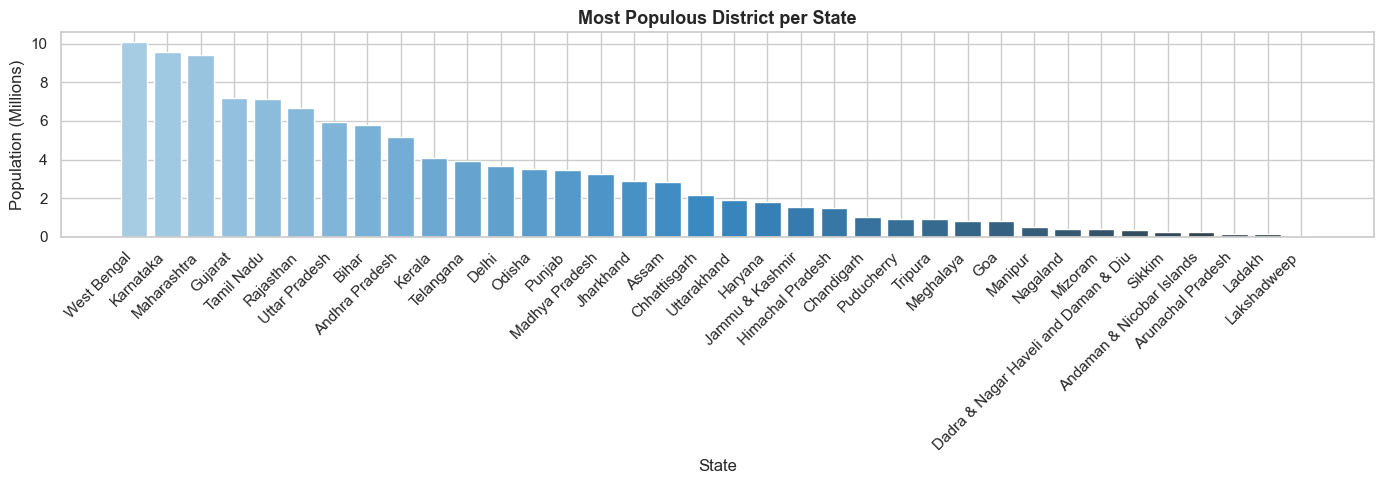

In [14]:
top_district = (
    dist_demo
    .loc[dist_demo.groupby("State")["Population"].idxmax()]
    [["State", "District", "Population"]]
    .sort_values("Population", ascending=False)
    .reset_index(drop=True)
)

display(top_district)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(top_district["State"], top_district["Population"] / 1e6,
       color=sns.color_palette("Blues_d", len(top_district)))
ax.set_title("Most Populous District per State", fontsize=13, fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel("Population (Millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 2.5 Average Transaction Value (ATV) per state

In [15]:
# Compute ATV from raw data rather than relying on pre-calculated column
atv = (
    state_txn
    .groupby("State")[["Amount (INR)", "Transactions"]]
    .sum()
)
atv["ATV (INR)"] = (atv["Amount (INR)"] / atv["Transactions"]).round(2)
atv = atv.sort_values("ATV (INR)", ascending=False)

print("Top 5 States — Highest ATV:")
display(atv[["ATV (INR)"]].head(5))

print("\nBottom 5 States — Lowest ATV:")
display(atv[["ATV (INR)"]].tail(5))

Top 5 States — Highest ATV:


,ATV (INR)
State,
Ladakh,"3,514.15"
Andaman & Nicobar Islands,"2,976.40"
Mizoram,"2,920.85"
Manipur,"2,905.76"
Nagaland,"2,794.14"



Bottom 5 States — Lowest ATV:


,ATV (INR)
State,
Delhi,"1,631.94"
West Bengal,"1,541.68"
Maharashtra,"1,514.29"
Dadra & Nagar Haveli and Daman & Diu,"1,497.23"
Karnataka,"1,463.04"


### 2.6 App usage trends

,State,Year,Quarter,App Opens
0,Andaman & Nicobar Islands,2018,1,0
1,Andaman & Nicobar Islands,2018,2,0
2,Andaman & Nicobar Islands,2018,3,0
3,Andaman & Nicobar Islands,2018,4,0
4,Andaman & Nicobar Islands,2019,1,0
5,Andaman & Nicobar Islands,2019,2,52640
6,Andaman & Nicobar Islands,2019,3,171107
7,Andaman & Nicobar Islands,2019,4,177012
8,Andaman & Nicobar Islands,2020,1,193586
9,Andaman & Nicobar Islands,2020,2,305072


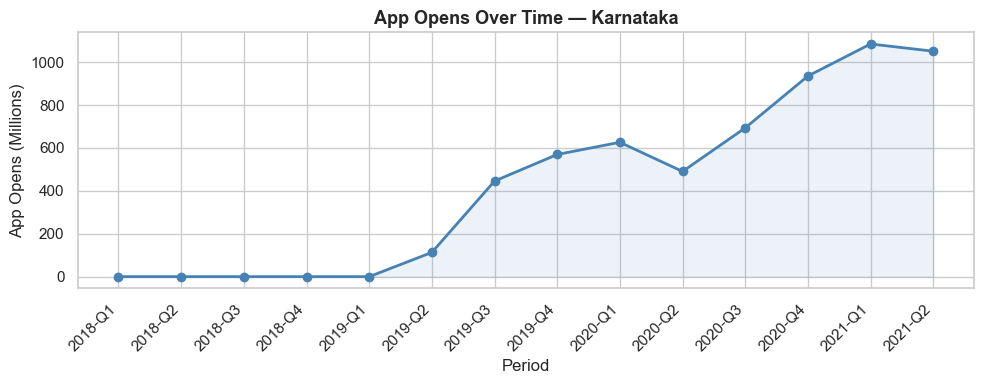

In [16]:
app_usage = (
    state_txn
    .groupby(["State", "Year", "Quarter"])["App Opens"]
    .sum()
    .reset_index()
)

display(app_usage.head(20))

# Trend for Karnataka
karnataka = app_usage[app_usage["State"] == "Karnataka"].sort_values(["Year", "Quarter"])
karnataka["Period"] = karnataka["Year"].astype(str) + "-Q" + karnataka["Quarter"].astype(str)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(karnataka["Period"], karnataka["App Opens"] / 1e6,
        marker="o", color="steelblue", linewidth=2)
ax.fill_between(karnataka["Period"], karnataka["App Opens"] / 1e6, alpha=0.1, color="steelblue")
ax.set_title("App Opens Over Time — Karnataka", fontsize=13, fontweight="bold")
ax.set_xlabel("Period")
ax.set_ylabel("App Opens (Millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 2.7 Transaction type distribution — most recent quarter

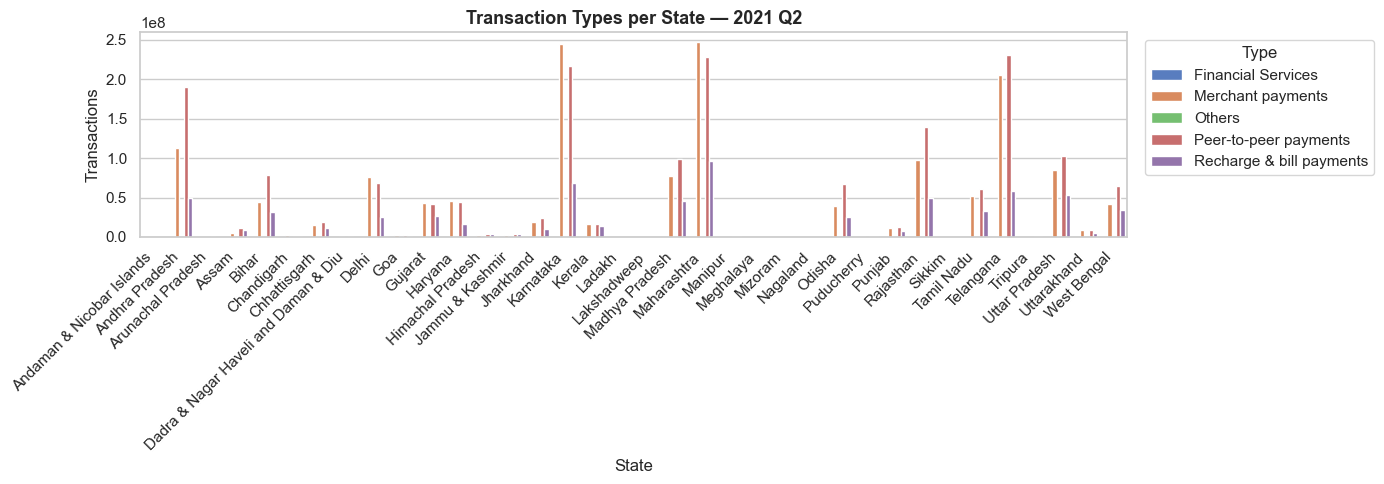

In [17]:
# Get the latest year and quarter in the data
latest_year = state_split["Year"].max()
latest_qtr  = state_split[state_split["Year"] == latest_year]["Quarter"].max()

latest = state_split[(state_split["Year"] == latest_year) & (state_split["Quarter"] == latest_qtr)]
txn_dist = latest.groupby(["State", "Transaction Type"])["Transactions"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=txn_dist, x="State", y="Transactions", hue="Transaction Type", ax=ax)
ax.set_title(f"Transaction Types per State — {latest_year} Q{latest_qtr}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel("Transactions")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 2.8 District name to code mapping — export to CSV

In [18]:
district_map = (
    dist_txn[["District", "Code"]]
    .drop_duplicates()
    .sort_values("District")
    .reset_index(drop=True)
)

print(f"Unique district-code mappings: {len(district_map)}")
display(district_map.head(10))

district_map.to_csv("district_code_mapping.csv", index=False)
print("Saved: district_code_mapping.csv")

Unique district-code mappings: 732


,District,Code
0,Adilabad,TG01
1,Agar Malwa,MP01
2,Agra,UP01
3,Ahmadabad,GJ01
4,Ahmednagar,MH01
5,Aizawl,MZ01
6,Ajmer,RJ01
7,Akola,MH02
8,Alappuzha,KL01
9,Aligarh,UP02


Saved: district_code_mapping.csv


---
## 🧭 Task 3 — Data Quality Checks

### 3.1 Do district totals match state totals?

In [19]:
COLS = ["Transactions", "Amount (INR)", "Registered Users"]

dist_sum  = dist_txn.groupby("State")[COLS].sum()
state_sum = state_txn.groupby("State")[COLS].sum()

# Align on common states to avoid index mismatch errors
common = dist_sum.index.intersection(state_sum.index)
diff   = (dist_sum.loc[common] - state_sum.loc[common]).abs()
discrepancies = diff[diff.any(axis=1)]

print(f"States checked   : {len(common)}")
print(f"Discrepancies    : {len(discrepancies)}")

if not discrepancies.empty:
    print("\nStates with mismatches:")
    display(discrepancies)
else:
    print("Data is consistent across district and state levels.")

States checked   : 36
Discrepancies    : 35

States with mismatches:


,Transactions,Amount (INR),Registered Users
State,,,
Andaman & Nicobar Islands,0,0.00,0
Andhra Pradesh,0,"672,444,670,176.61",0
Arunachal Pradesh,0,0.00,0
Assam,0,0.00,0
Bihar,0,0.00,0
Chandigarh,0,0.00,0
Chhattisgarh,0,0.00,0
Dadra & Nagar Haveli and Daman & Diu,0,0.00,0
Delhi,0,0.00,0


---
##  🧭 Task 4 — Data Merging and Advanced Analysis

### 4.1 Ratio of registered users to population by state

,State,Registered Users,Population,User_Pop_Ratio
0,Delhi,95374654,16787941,5.68
1,Dadra & Nagar Haveli and Daman & Diu,2701112,586956,4.60
2,Telangana,149224214,36366570,4.10
3,Chandigarh,3801466,1055450,3.60
4,Karnataka,203098564,60965960,3.33
5,Haryana,85564119,25855357,3.31
6,Goa,4755320,1457723,3.26
7,Andhra Pradesh,158007957,49378776,3.20
8,Maharashtra,315783658,112378989,2.81
9,Uttarakhand,23792747,10116752,2.35


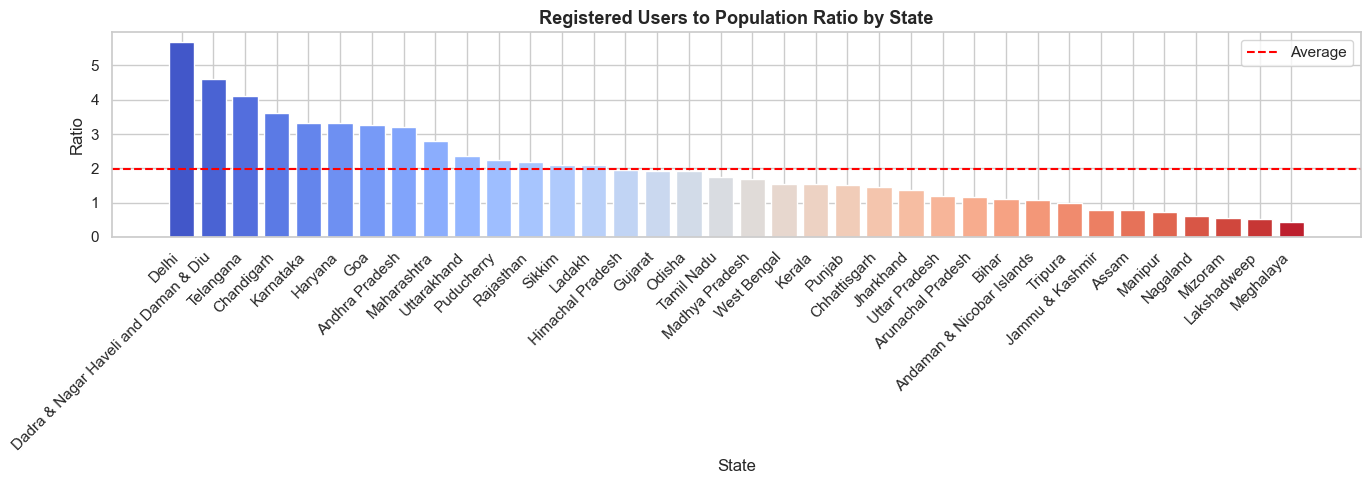

In [20]:
state_pop   = dist_demo.groupby("State")["Population"].sum().reset_index()
state_users = state_txn.groupby("State")["Registered Users"].sum().reset_index()

user_pop = (
    pd.merge(state_users, state_pop, on="State")
    .assign(**{"User_Pop_Ratio": lambda d: (d["Registered Users"] / d["Population"]).round(4)})
    .sort_values("User_Pop_Ratio", ascending=False)
    .reset_index(drop=True)
)

display(user_pop)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(user_pop["State"], user_pop["User_Pop_Ratio"],
       color=sns.color_palette("coolwarm", len(user_pop)))
ax.axhline(user_pop["User_Pop_Ratio"].mean(),
           color="red", linestyle="--", label="Average")
ax.set_title("Registered Users to Population Ratio by State", fontsize=13, fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel("Ratio")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.2 Population density vs transaction volume — correlation

Correlation — Population vs Transactions: 0.4891


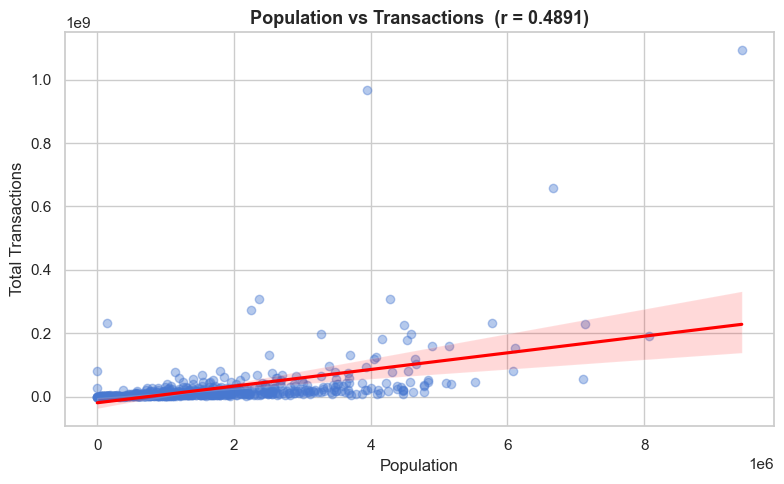

In [21]:
dist_merged = pd.merge(
    dist_txn.groupby("District")[["Transactions", "Amount (INR)"]].sum().reset_index(),
    dist_demo[["District", "Population", "Density"]],
    on="District"
)

corr = dist_merged["Population"].corr(dist_merged["Transactions"]).round(4)
print(f"Correlation — Population vs Transactions: {corr}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=dist_merged, x="Population", y="Transactions",
            ax=ax, scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
ax.set_title(f"Population vs Transactions  (r = {corr})", fontsize=13, fontweight="bold")
ax.set_xlabel("Population")
ax.set_ylabel("Total Transactions")
plt.tight_layout()
plt.show()

### 4.3 Average transaction amount per user

In [22]:
avg_txn = (
    state_txn
    .groupby("State")[["Amount (INR)", "Registered Users"]]
    .sum()
    .assign(**{"Avg_Txn_per_User": lambda d: (d["Amount (INR)"] / d["Registered Users"]).round(2)})
    .sort_values("Avg_Txn_per_User", ascending=False)
)

print("Top 5 — Highest Avg Transaction Amount per User:")
display(avg_txn[["Avg_Txn_per_User"]].head(5))

print("\nBottom 5 — Lowest Avg Transaction Amount per User:")
display(avg_txn[["Avg_Txn_per_User"]].tail(5))

Top 5 — Highest Avg Transaction Amount per User:


,Avg_Txn_per_User
State,
Telangana,"30,653.51"
Karnataka,"21,474.28"
Andhra Pradesh,"20,175.23"
Rajasthan,"17,530.77"
Delhi,"17,299.59"



Bottom 5 — Lowest Avg Transaction Amount per User:


,Avg_Txn_per_User
State,
Himachal Pradesh,"7,317.60"
Kerala,"7,274.85"
Dadra & Nagar Haveli and Daman & Diu,"6,907.82"
Tripura,"5,727.18"
Lakshadweep,"5,614.90"


### 4.4 Device brand usage ratio

,State,Brand,Registered Users,Total_Users,Usage_Ratio
268,Manipur,Xiaomi,1079740,2317734,0.47
168,Jammu & Kashmir,Xiaomi,3471820,9756438,0.36
293,Mizoram,Xiaomi,193013,605612,0.32
368,Sikkim,Samsung,406392,1279199,0.32
306,Nagaland,Xiaomi,440693,1440387,0.31
156,Himachal Pradesh,Xiaomi,3978888,13373980,0.30
60,Bihar,Xiaomi,33721314,115284760,0.29
216,Ladakh,Xiaomi,167017,579825,0.29
182,Jharkhand,Xiaomi,12824023,44768682,0.29
318,Odisha,Xiaomi,22935907,80404103,0.29


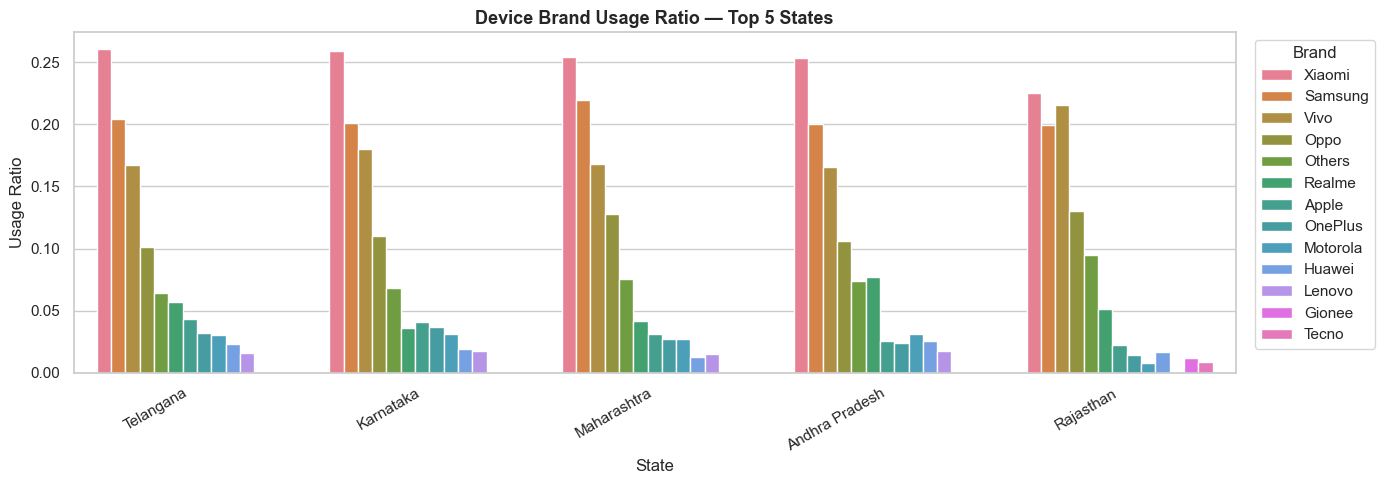

In [23]:
total_users = state_txn.groupby("State")["Registered Users"].sum().reset_index()
total_users.columns = ["State", "Total_Users"]

brand_users = state_device.groupby(["State", "Brand"])["Registered Users"].sum().reset_index()

device_ratio = (
    pd.merge(brand_users, total_users, on="State")
    .assign(**{"Usage_Ratio": lambda d: (d["Registered Users"] / d["Total_Users"]).round(4)})
    .sort_values("Usage_Ratio", ascending=False)
)

display(device_ratio.head(15))

# Chart for top 5 states only (keeps it readable)
top5 = state_totals.head(5).index.tolist()
plot_data = device_ratio[device_ratio["State"].isin(top5)]

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=plot_data, x="State", y="Usage_Ratio", hue="Brand", ax=ax)
ax.set_title("Device Brand Usage Ratio — Top 5 States", fontsize=13, fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel("Usage Ratio")
plt.legend(title="Brand", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
##  🧭 Task 5 — Data Visualisation

### 5.1 Transactions and amount over time — Kerala

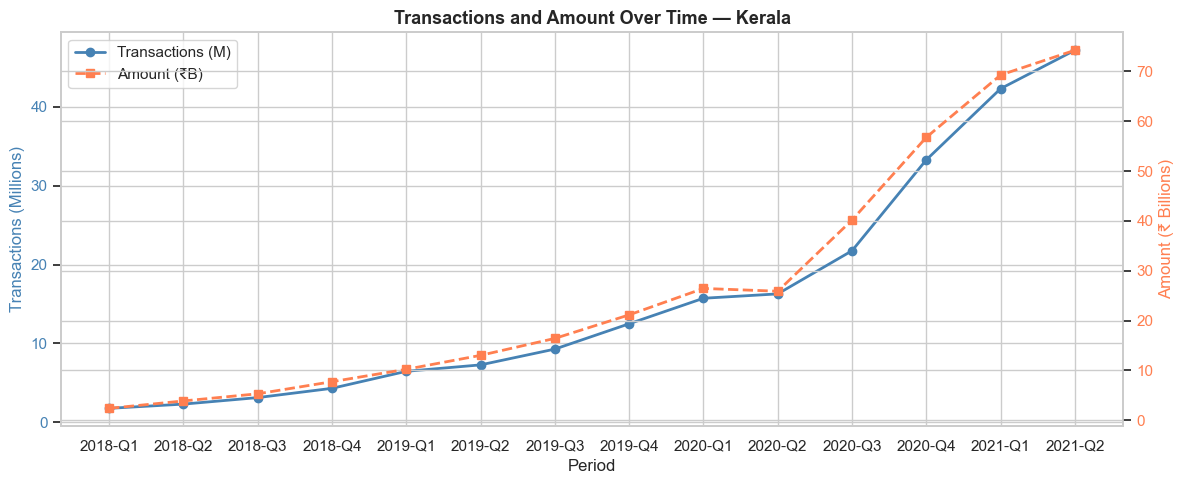

In [24]:
kerala = (
    state_txn[state_txn["State"] == "Kerala"]
    .sort_values(["Year", "Quarter"])
    .assign(Period=lambda d: d["Year"].astype(str) + "-Q" + d["Quarter"].astype(str))
)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(kerala["Period"], kerala["Transactions"] / 1e6,
         color="steelblue", marker="o", linewidth=2, label="Transactions (M)")
ax1.set_ylabel("Transactions (Millions)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(kerala["Period"], kerala["Amount (INR)"] / 1e9,
         color="coral", marker="s", linewidth=2, linestyle="--", label="Amount (₹B)")
ax2.set_ylabel("Amount (₹ Billions)", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper left")
ax1.set_title("Transactions and Amount Over Time — Kerala", fontsize=13, fontweight="bold")
ax1.set_xlabel("Period")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.2 Transaction type distribution — Kerala, Q2

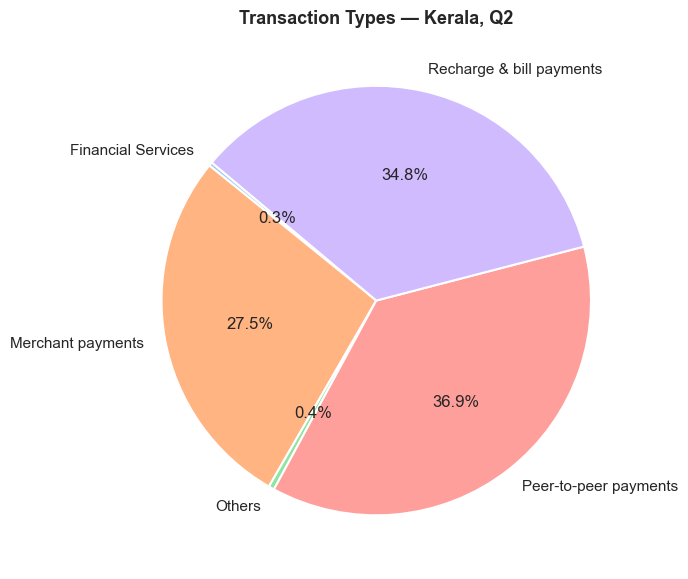

In [25]:
kerala_q2 = (
    state_split[(state_split["State"] == "Kerala") & (state_split["Quarter"] == 2)]
    .groupby("Transaction Type")["Transactions"]
    .sum()
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    kerala_q2,
    labels=kerala_q2.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel"),
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax.set_title("Transaction Types — Kerala, Q2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 Population density by district — Kerala

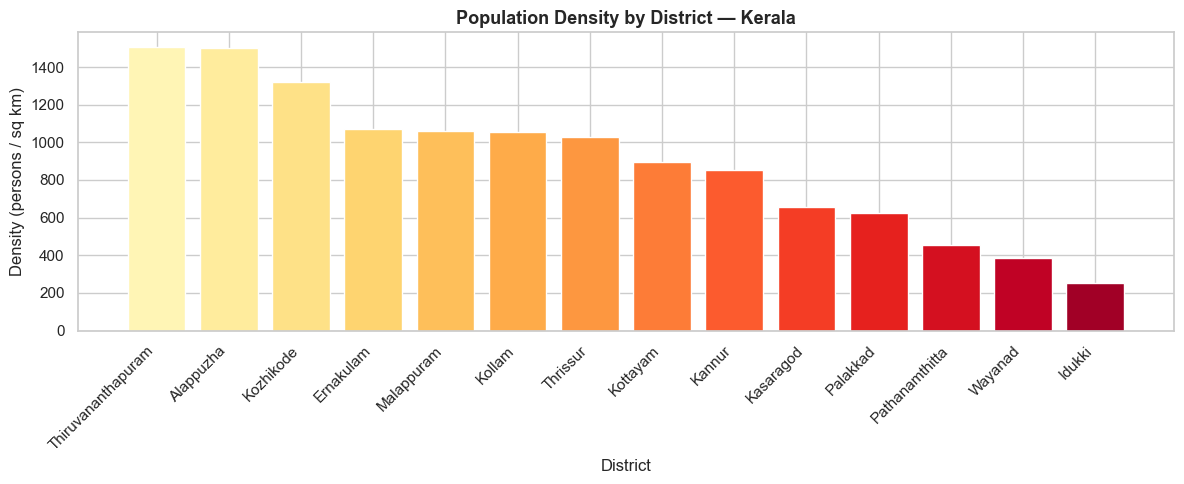

In [26]:
kerala_demo = dist_demo[dist_demo["State"] == "Kerala"].sort_values("Density", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(kerala_demo["District"], kerala_demo["Density"],
       color=sns.color_palette("YlOrRd", len(kerala_demo)))
ax.set_title("Population Density by District — Kerala", fontsize=13, fontweight="bold")
ax.set_xlabel("District")
ax.set_ylabel("Density (persons / sq km)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 🧭  Task 6 — Insights and Conclusions

### 6.1 National transaction trends

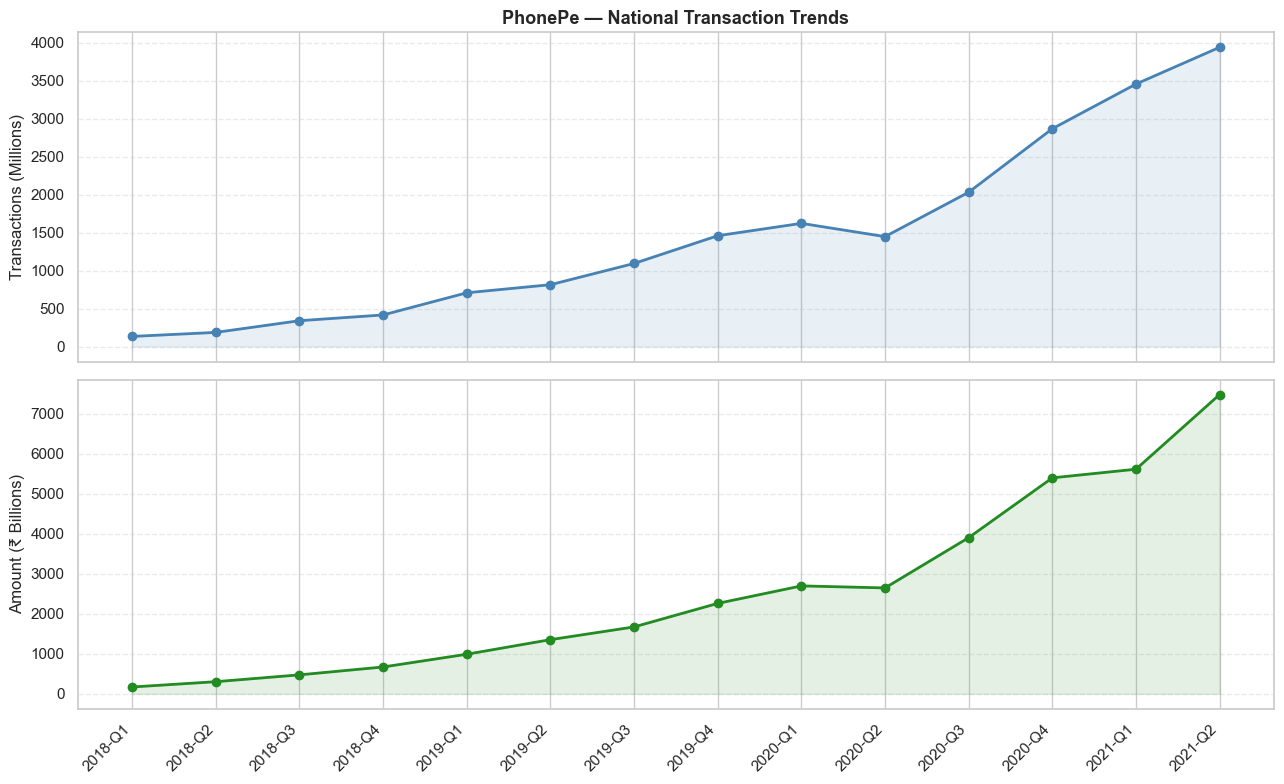


Observations:
─────────────
• Transactions and total amount show consistent YoY growth.
• Q3 and Q4 tend to spike — likely driven by festive season spending.
• The growth in amount outpaces transaction count, meaning users are
  sending larger values over time — a sign of growing trust in the platform.



In [27]:
national = (
    state_txn
    .groupby(["Year", "Quarter"])[["Transactions", "Amount (INR)", "App Opens"]]
    .sum()
    .reset_index()
    .sort_values(["Year", "Quarter"])
    .assign(Period=lambda d: d["Year"].astype(str) + "-Q" + d["Quarter"].astype(str))
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for ax, col, color, label in zip(
    axes,
    ["Transactions",  "Amount (INR)"],
    ["steelblue",     "forestgreen"],
    ["Transactions (Millions)", "Amount (₹ Billions)"]
):
    scale = 1e6 if col == "Transactions" else 1e9
    ax.plot(national["Period"], national[col] / scale,
            color=color, marker="o", linewidth=2)
    ax.fill_between(national["Period"], national[col] / scale, alpha=0.12, color=color)
    ax.set_ylabel(label)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_title("PhonePe — National Transaction Trends", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("""
Observations:
─────────────
• Transactions and total amount show consistent YoY growth.
• Q3 and Q4 tend to spike — likely driven by festive season spending.
• The growth in amount outpaces transaction count, meaning users are
  sending larger values over time — a sign of growing trust in the platform.
""")

### 6.2 Demographic correlations

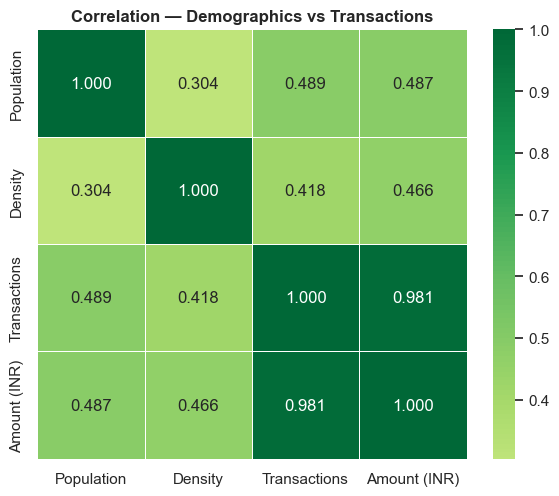


Findings:
─────────
• Population vs Transactions  : r = 0.489
• Density vs Transactions     : r = 0.418

Population correlates more strongly with transactions than density does.
This means total population size drives usage more than how densely packed
an area is — PhonePe's reach extends into rural districts, not just cities.



In [28]:
corr_matrix = dist_merged[["Population", "Density", "Transactions", "Amount (INR)"]].corr().round(3)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation — Demographics vs Transactions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"""
Findings:
─────────
• Population vs Transactions  : r = {dist_merged['Population'].corr(dist_merged['Transactions']):.3f}
• Density vs Transactions     : r = {dist_merged['Density'].corr(dist_merged['Transactions']):.3f}

Population correlates more strongly with transactions than density does.
This means total population size drives usage more than how densely packed
an area is — PhonePe's reach extends into rural districts, not just cities.
""")

### 6.3 Summary and Recommendations

In [29]:
print("""
KEY FINDINGS
============

1. Growth     : PhonePe shows strong and consistent growth in both transaction
                count and total amount year over year.

2. Geography  : Maharashtra, Karnataka, and Telangana lead in volume.
                Smaller states still show healthy usage — wide national reach.

3. Devices    : Xiaomi and Samsung dominate in most states, pointing to a
                core mid-range Android user base.

4. Txn Types  : Peer-to-peer transfers and recharge/bill payments are the
                most frequent types — everyday utility drives engagement.

5. Demographics: Population size is a stronger predictor of transaction volume
                 than density — rural India is actively using PhonePe.


RECOMMENDATIONS
===============

• Target Tier-2/3 cities and rural districts — adoption headroom is high.
• Optimize app performance for Xiaomi and Samsung mid-range devices.
• Run festive-season campaigns in Q3–Q4 to capitalize on spending peaks.
• Investigate states with high ATV but low volume — potential for growth.
• Fix data pipeline discrepancies between district and state rollups.
""")


KEY FINDINGS

1. Growth     : PhonePe shows strong and consistent growth in both transaction
                count and total amount year over year.

2. Geography  : Maharashtra, Karnataka, and Telangana lead in volume.
                Smaller states still show healthy usage — wide national reach.

3. Devices    : Xiaomi and Samsung dominate in most states, pointing to a
                core mid-range Android user base.

4. Txn Types  : Peer-to-peer transfers and recharge/bill payments are the
                most frequent types — everyday utility drives engagement.

5. Demographics: Population size is a stronger predictor of transaction volume
                 than density — rural India is actively using PhonePe.


RECOMMENDATIONS

• Target Tier-2/3 cities and rural districts — adoption headroom is high.
• Optimize app performance for Xiaomi and Samsung mid-range devices.
• Run festive-season campaigns in Q3–Q4 to capitalize on spending peaks.
• Investigate states with high ATV but lo